# EE6201: Power Systems Lab - Assignment 05  
## Modeling and Analysis of a Grid-Connected Two-Level Switching Pole

### Objective

The objective of this assignment is to model a two-level switching pole connected to an AC grid through an inductor, derive its governing differential equation using a switching function approach, and analyze its behavior under different modulation strategies.

The harmonic characteristics of the pole voltage and injected current are also studied using Fourier analysis.

## 1. System Description

The system consists of a two-level switching pole connected to an AC grid through an inductor.

- DC link voltage: $V_{dc}$
- Grid voltage: 
$$
v_g(t) = V_g \sin(\omega_0 t)
$$
- Inductor: $L$
- Injected current: $i(t)$

The switching pole generates a pole voltage that alternates between two levels depending on the switching state.

The inductor acts as an interface between the converter and the grid and controls the current injected into the grid.

## 2. Switching Function Representation

The switching behavior is represented using a switching function $s(t)$ defined as:

$$
s(t) =
\begin{cases}
+1, & \text{if } S_a^+ \text{ is ON and } S_a^- \text{ is OFF} \\
-1, & \text{if } S_a^+ \text{ is OFF and } S_a^- \text{ is ON}
\end{cases}
$$

The pole voltage is expressed as:

$$
v_p(t) = \frac{V_{dc}}{2} \, s(t)
$$

## 3. Derivation of the System Model

### Step 1: Apply KVL

Applying Kirchhoff’s Voltage Law:

$$
v_p(t) = v_L(t) + v_g(t)
$$

---

### Step 2: Inductor Voltage

$$
v_L(t) = L \frac{di(t)}{dt}
$$

---

### Step 3: Substitute

$$
v_p(t) = L \frac{di(t)}{dt} + v_g(t)
$$

---

### Step 4: Rearranging

$$
L \frac{di(t)}{dt} = v_p(t) - v_g(t)
$$

---

### Step 5: Substitute switching function

$$
L \frac{di(t)}{dt} = \frac{V_{dc}}{2} s(t) - V_g \sin(\omega_0 t)
$$

---

### Final Equation

$$
\frac{di(t)}{dt} = \frac{1}{L} \left( \frac{V_{dc}}{2} s(t) - V_g \sin(\omega_0 t) \right)
$$

This is a first-order differential equation describing the system dynamics.

## 4. System Simulation

The derived differential equation is solved numerically using Python.

The simulation involves:

- Generating the switching function $s(t)$
- Computing the pole voltage $v_p(t)$
- Defining the grid voltage $v_g(t)$
- Solving the differential equation using a numerical solver

Typical parameters used:

- $V_{dc}$
- $V_g$
- $L$
- Fundamental frequency $f_1$
- Switching frequency $f_sw$

## 5. Switching Strategies

Three switching strategies are analyzed:

---

### 5.1 Square Wave Switching

$$
s(t) = \text{sign}(\sin(\omega_0 t))
$$

Produces a square wave output with strong low-frequency harmonics.

---

### 5.2 Sine-Triangle PWM (SPWM)

- Reference: sinusoidal signal
- Carrier: triangular wave

Switching rule:

$$
s(t) =
\begin{cases}
+1, & v_{ref}(t) \geq v_{carrier}(t) \\
-1, & \text{otherwise}
\end{cases}
$$

Shifts harmonics to higher frequencies.

---

### 5.3 Sine-Sawtooth PWM

Same as SPWM, but using a sawtooth carrier.

Results in a different harmonic distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy import signal
from scipy.interpolate import interp1d

In [2]:
class PWM:
    def __init__(self,Ma,fr,fc,lvl=0):
        self.Ma = Ma # Modulating Index
        self.fr = fr # Reference Waveform Frequency
        self.fc = fc # Switching Frequency of Converter
        self.Ac = 1
        self.Ar = self.Ma
        self.lvl = lvl
        # Ma = Ar/Ac
#---------------------------------------------------------------------#
    def SquareWave(self,t,prt_flag=0):
        Wr = 2*np.pi*self.fr
        sw_square = np.sign(np.sin(Wr * t))
        #sw_square_func = interp1d(t,sw_square,fill_value="extrapolate")
        if prt_flag == 1:
            plt.plot(t,sw_square)
            plt.xlabel("Time (s)"); plt.title("Switching Scheme")
            plt.grid(); plt.show()
        return sw_square
#---------------------------------------------------------------------#
    def SineTriangle(self,t,prt_flag=0):
        Wr = 2 * np.pi * self.fr
        ref = self.Ar * np.sin(Wr * t) # Reference Wave
        Wc = 2 * np.pi * self.fc
        carrier = -self.Ac * signal.sawtooth(Wc*t, 0.5) # Carrier Wave
        sw_spwm = np.where(ref > carrier,1,-1) # Comparison between the two
        #sw_spwm_func = interp1d(t,sw_spwm,fill_value="extrapolate")
        
        if prt_flag == 1:
            print("Came Here")
            plt.plot(t,ref)
            plt.plot(t,carrier)
            plt.xlabel("Time (s)"); plt.title("Switching Scheme")
            plt.grid(); plt.show()
        return sw_spwm
#---------------------------------------------------------------------#
    def SineSawtooth(self,t,prt_flag=0):
        Wr = 2 * np.pi * self.fr
        ref = self.Ar * np.sin(Wr * t) # Reference Wave
        Wc = 2 * np.pi * self.fc
        carrier = -self.Ac * signal.sawtooth(Wc*t, 1) # Carrier Wave
        sw_saw = np.where(ref > carrier,1,-1)
        #sw_saw_func = interp1d(t,sw_saw,fill_value="extrapolate") #solving ODE using solver of scipy

        if prt_flag == 1:
            plt.plot(t,ref)
            plt.plot(t,carrier)
            plt.xlabel("Time (s)"); plt.title("Switching Scheme")
            plt.grid(); plt.show()
        return sw_saw

In [3]:
class VSC:
    def __init__(self,Vdc,f0,fsw,pwm,tstart,tend,lvl = 0,Ma = 1,X = 300):
        self.Vdc = Vdc # DC Bridge Voltage
        self.tstart = tstart
        self.tend = tend
        self.lvl = lvl

        self.f0 = f0 # Fundamental Component Frequency
        self.fsw = fsw # Switching Frequency
        self.pwm = pwm
        self.Ma = Ma
        self.X = X
        
        # Unit Pulse Generation
        self.f_ratio = int(self.fsw / self.f0)
        self.N = self.f_ratio * self.X
        self.f_smpl = self.N * self.f0
        self.__step_s = 1 / (self.f_smpl)
        self.__t_s = np.arange(self.tstart, self.tend, self.__step_s)
        
        self.__V = self.__obtainVoltage(self.__t_s)

        # ORIGINAL VOLTAGE GENERATION for PLOTTING ONLY
        self.__step = 1 / (self.fsw * 1000)
        self.__t_orig = np.arange(self.tstart,self.tend,self.__step)
        self.__Vo = self.__obtainVoltage(self.__t_orig)

    def __obtainVoltage(self,t):
        sw_pwm = PWM(self.Ma,self.f0,self.fsw,self.lvl)
        if self.lvl == 0:
            pwm = self.pwm
            if pwm == 'square':
                sw_seq = sw_pwm.SquareWave(t)
            elif pwm == 'sine-triangle':
                sw_seq = sw_pwm.SineTriangle(t)
            elif pwm == 'sine-sawtooth':
                sw_seq = sw_pwm.SineSawtooth(t)
            else:
                raise ValueError("PWM scheme '{}' not recognised. Choose from: 'square', 'sine-triangle', 'sine-sawtooth'".format(pwm))
            V = (self.Vdc/2) * sw_seq
        else:
            pwm = self.pwm
            if pwm == 'pd':
                sw_seq = sw_pwm.PhaseDisposition(t)
            elif pwm == 'apod':
                sw_seq = sw_pwm.SineTriangle(t)
            elif pwm == 'pod':
                sw_seq = sw_pwm.SineSawtooth(t)
            else:
                raise ValueError("PWM scheme '{}' not recognised. Choose from: 'pd', 'apod', 'pod'".format(pwm))
            V = (self.Vdc/(self.lvl-1)) * sw_seq
        return V

    def plotWaveform(self, tlim=None):
        plt.figure()
        plt.plot(self.__t_orig, self.__Vo, 'b-', label='Original Signal', lw=3)
        plt.plot(self.__t_s,self.__V,'ro',label = 'Sampled Points')
        plt.title("Pole Output Voltage for {} Scheme".format(self.pwm))
        plt.xlabel('Time (s)',fontsize=10); plt.ylabel('Voltage (V)',fontsize=10)
        if tlim is not None:
            plt.xlim(tlim[0], tlim[1])
        plt.legend(); plt.grid(); plt.show()

    def getValues(self):
        return self.__V, self.__t_s

    def getInterpldFcn(self):
        V_fcn = interp1d(self.__t_s,self.__V,fill_value="extrapolate")
        return V_fcn

In [4]:
class DFT:
    def __init__(self,y,N):
        self.y = y
        self.N = N
        self.__W0 = 2 * np.pi / self.N
        self.__tot_wndw = self.y.size - self.N + 1
        self.__wndw = self.__tot_wndw - 1
        self.__C = self.__generateCoeff(self.__wndw)
        self.__cF = np.array([np.exp(-1j * self.__W0 * i) for i in range(self.__tot_wndw)])
    
    def __generateCoeff(self,W):
        #mtrxDFT = (1/self.N) * np.array([[np.exp(-self.__W0*1j*col*row) for col in range(0,self.N)] for row in range(0,self.N)])
        row = np.arange(self.N)
        col = np.arange(self.N)
        mtrxDFT = (1/self.N) * np.exp(-self.__W0 * 1j * np.outer(row,col))
        dft_Ck = self.y[W:self.N+W]@mtrxDFT # Coefficients are calculated for W-th Window
        return dft_Ck
    
    def slide_dft(self,M):
        # M is the M-th Coefficient of the signal
        mtrxC_M = np.array([np.exp(-1j * self.__W0 * i * M) for i in range(0,self.N)])
        slide_raw =  (np.sqrt(2)/self.N) * np.array([self.y[i:(self.N + i)]@mtrxC_M for i in range(0,self.__tot_wndw)])
        slide_C = slide_raw #* self.__cF
        return slide_C

    def recur_dft(self,M):
        recur_raw = np.zeros(self.__tot_wndw ,dtype=complex)
        mtrxC_M = np.array([np.exp(-1j * self.__W0 * i * M) for i in range(0,self.N)])
        
        phs_shft = np.exp(1j * self.__W0 * M)
        C1_0 = (np.sqrt(2)/self.N) * self.y[0:self.N]@mtrxC_M
        recur_raw[0] = C1_0
        for i in range(1,self.__tot_wndw):
            recur_raw[i] = (recur_raw[i-1] + (np.sqrt(2)/self.N) * (self.y[i+self.N-1] - self.y[i-1]))*phs_shft
        
        recur_C = recur_raw #* self.__cF
        return recur_C

    def plotSpectrum(self,bin_lim = None):
        magnC = abs(self.__C)
        phaseC = np.angle(self.__C,deg = True)    
        if bin_lim is None:
            bin_lim = self.N
        plt.stem(np.arange(0,bin_lim),magnC[0:bin_lim])
        plt.title('DFT Magnitude Spectrum — Window {a}'.format(a = self.__wndw))
        plt.xlabel('Bin k'); plt.ylabel('Magnitude')
        plt.grid(); plt.show()
        
        plt.stem(np.arange(0,bin_lim),phaseC[0:bin_lim])
        plt.title('DFT Phase Spectrum — Window {a}'.format(a = self.__wndw))
        plt.xlabel('Bin k'); plt.ylabel('Phase (°)')
        plt.grid(); plt.show()
        
    def computePhasor(self):
        phasor_C = np.sqrt(2) * self.__C
        return phasor_C

    def computeTHD(self):
        phsrC = self.computePhasor()
        C_1 = abs(phsrC[1])
        C_not01 = abs(phsrC[2:self.N//2:])
        THD = (np.sqrt(np.sum(np.square(C_not01))) / C_1) * 100
        return THD
        
    def getValues(self):
        return self.__C    

In [5]:
class GridInjection:
    def __init__(self,Vg,r,L,f0,fsw,Vin,t,step=10):
        self.Vg = Vg
        self.r = r
        self.L = L
        self.f0 = f0
        self.fsw = fsw
        self.Vin = Vin
        self.t = t
        self.W0 = 2 * np.pi * self.f0

        self.step = step
        self.__out = self.__solveODE()
    def __IL(self,i,t):
        Vg = np.sqrt(2) * self.Vg * np.sin(self.W0 * t)
        Vp = self.Vin(t)
        return (Vp - Vg - self.r * i) / self.L
    def __solveODE(self):
        soln = solve_ivp(lambda t,i: self.__IL(i,t),
                   [0,self.t[-1]],
                   [0],
                   t_eval=self.t,
                  max_step=1/(self.fsw*self.step))
        if soln.success:
            return soln.y[0]
    def getValues(self):
        return self.__out
    def plotWaveform(self,tlim = None):
        plt.plot(self.t,self.__out)
        plt.xlabel("Time (s)"); plt.ylabel("Current (A)")
        plt.title("Injected Current Waveform")
        if tlim is not None:
            plt.xlim(tlim[0], tlim[1])
        plt.grid(); plt.show()

In [6]:
def getResults(Vdc,f1,fsw,pwm,levels,Ma,tstart,tend,Vg,L,R):
    vsc = VSC(Vdc,f1,fsw,pwm,tstart,tend,levels,Ma)
    V,t = vsc.getValues()
    print("Converter Object Made")
    dft_V = DFT(V,vsc.N)
    V_f = (abs(dft_V.getValues()[1]) + abs(dft_V.getValues()[-1]))/np.sqrt(2)
    print("Voltage DFT Computed")
    grd_injc = GridInjection(Vg,R,L,f1,fsw,vsc.getInterpldFcn(),t)
    I = grd_injc.getValues()
    print("Grid Injection Equation Solved")
    dft_I = DFT(I,vsc.N)
    I_f = (abs(dft_I.getValues()[1]) + abs(dft_I.getValues()[-1]))/np.sqrt(2)
    print("Current DFT Computed")
    print("All Done!!!")
    
    return vsc,dft_V,V_f,grd_injc,dft_I,I_f

In [7]:
# DEFINING SIMULATION PARAMETERS
Vdc = 400 # DC Bridge Voltage
tstart=0
tend = 1000e-3 # Total Simulation Time
f1 = 50 # Output Fundamental Frequency
fsw = 3550 # High Switching Frequency
fsw_low = 350 # Low Switching Frequency
Ma = 0.8 # Modulation Index

Vg = 150 # Grid Voltage 
L  = 10e-3 # Grid Inductance
R = 0.5 # Grid Resistance required for removing the DC transients


In [8]:
#-------------------------------------------------------------------------------------------------------------#
VSC1,sqV1,Vsq_f,sqInjctn,dftIsq,Isq_f = getResults(Vdc,f1,fsw,'square',0,Ma,tstart,tend,Vg,L,R)
print("*--------------------------------------------*")
VSC2,sineTriV2,Vsine_trif,sineTriInjctn,dftIspwm,IsineTri_f = getResults(Vdc,f1,fsw,'sine-triangle',0,Ma,tstart,tend,Vg,L,R)
print("*--------------------------------------------*")
VSC3,sineSawV3,Vsine_swf,sineSawInjctn,dftIsaw,IsineSaw_f = getResults(Vdc,f1,fsw,'sine-sawtooth',0,Ma,tstart,tend,Vg,L,R)
print("*--------------------------------------------*")
VSC4,sqV4,Vsq_f1,sqInjctn1,dftIsq1,Isq_f1 = getResults(Vdc,f1,fsw_low,'square',0,Ma,tstart,tend,Vg,L,R)
print("*--------------------------------------------*")
VSC5,sineTriV5,Vsine_trif1,sineTriInjctn1,dftIspwm1,IsineTri_f1 = getResults(Vdc,f1,fsw_low,'sine-triangle',0,Ma,tstart,tend,Vg,L,R)
print("*--------------------------------------------*")
VSC6,sineSawV6,Vsine_swf1,sineSawInjctn1,dftIsaw1,IsineSaw_f1 = getResults(Vdc,f1,fsw_low,'sine-sawtooth',0,Ma,tstart,tend,Vg,L,R)
print("*--------------------------------------------*")

Converter Object Made
Voltage DFT Computed
Grid Injection Equation Solved
Current DFT Computed
All Done!!!
*--------------------------------------------*
Converter Object Made
Voltage DFT Computed
Grid Injection Equation Solved
Current DFT Computed
All Done!!!
*--------------------------------------------*
Converter Object Made
Voltage DFT Computed
Grid Injection Equation Solved
Current DFT Computed
All Done!!!
*--------------------------------------------*
Converter Object Made
Voltage DFT Computed
Grid Injection Equation Solved
Current DFT Computed
All Done!!!
*--------------------------------------------*
Converter Object Made
Voltage DFT Computed
Grid Injection Equation Solved
Current DFT Computed
All Done!!!
*--------------------------------------------*
Converter Object Made
Voltage DFT Computed
Grid Injection Equation Solved
Current DFT Computed
All Done!!!
*--------------------------------------------*


FOR AN fsw: 350 Hz
Pole Voltage Fundamental RMS for square scheme: 180.063 V, sine-triangle scheme: 113.358 V, sine-sawtooth scheme: 112.977 V
*--------------------------------------------*
FOR AN fsw: 3550 Hz
Pole Voltage Fundamental RMS for square scheme: 180.063 V, sine-triangle scheme: 113.027 V, sine-sawtooth scheme: 113.046 V
*--------------------------------------------*
FOR AN fsw: 350 Hz
Pole Voltage THD for square scheme: 48.342 %, sine-triangle scheme: 145.356 %, sine-sawtooth scheme: 146.075 %
*--------------------------------------------*
FOR AN fsw: 3550 Hz
Pole Voltage THD for square scheme: 48.343 %, sine-triangle scheme: 145.983 %, sine-sawtooth scheme: 145.947 %
*--------------------------------------------*
SQUARE MODE Voltages


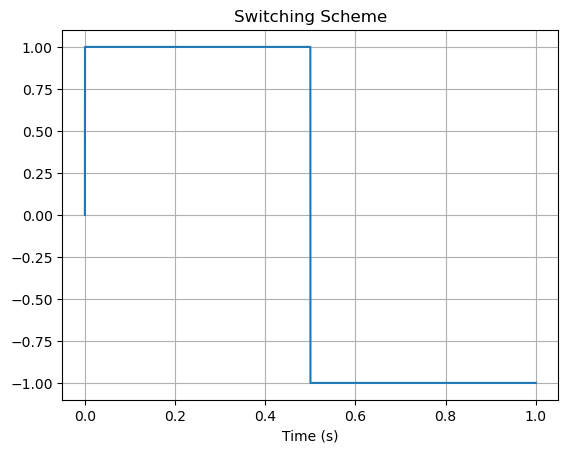

fsw: 350 Hz


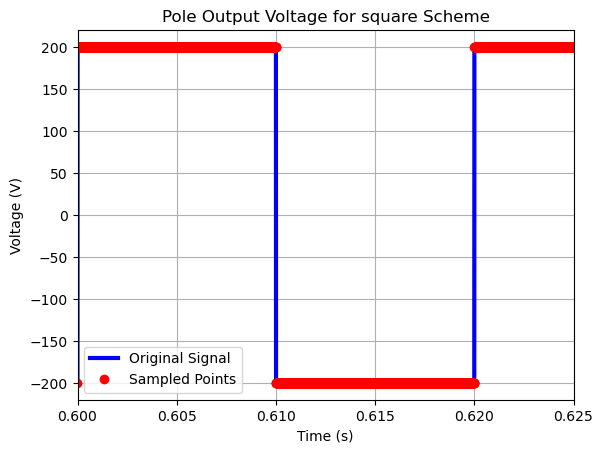

fsw: 3550 Hz


C:\Users\abdul\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


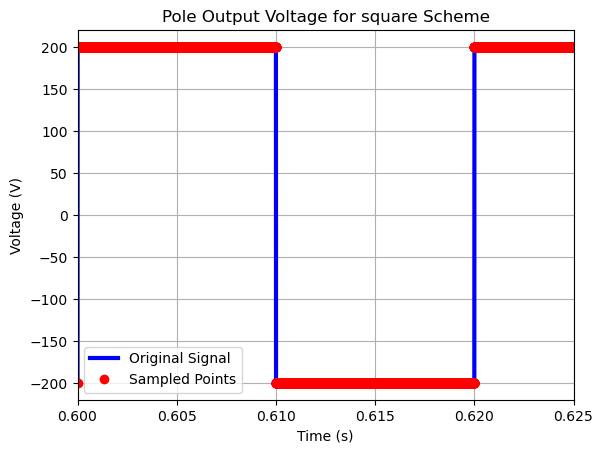

SINE-TRIANGLE MODE Voltages
Came Here


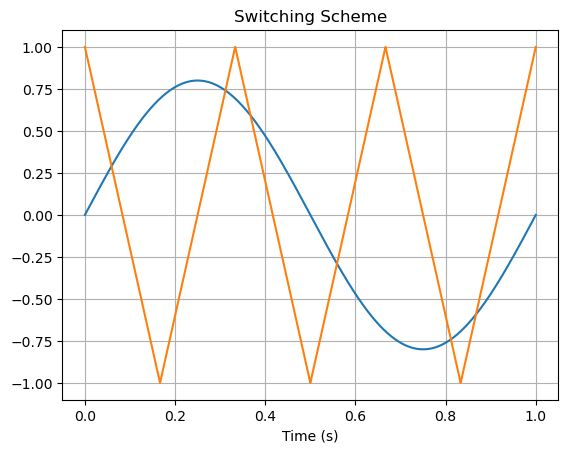

fsw: 350 Hz


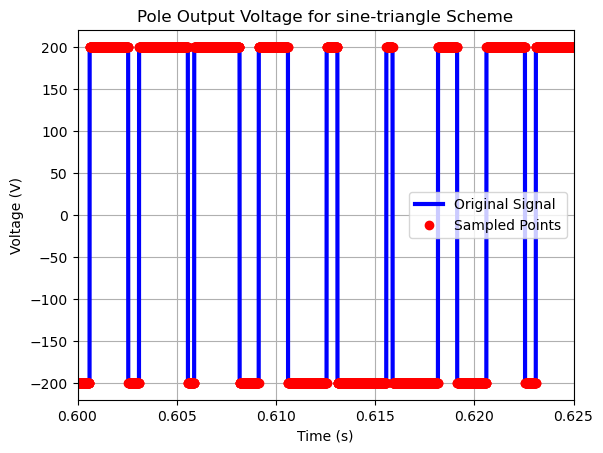

fsw: 3550 Hz


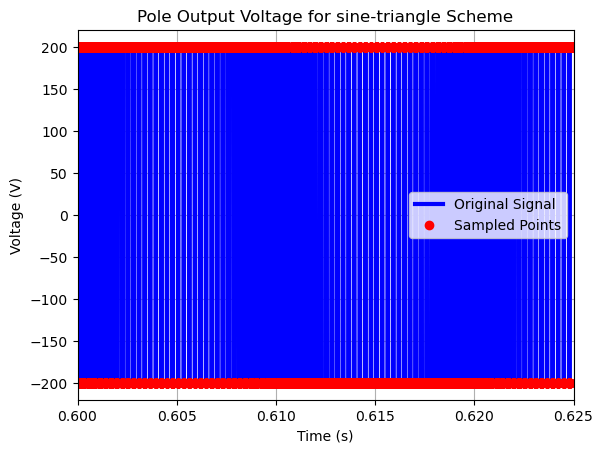

SINE-SAWTOOTH MODE Voltages


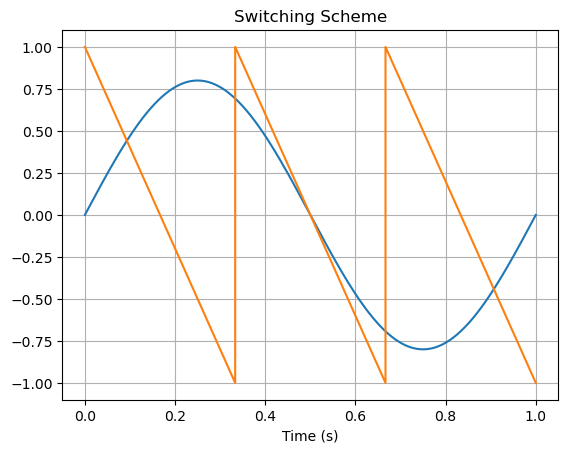

fsw: 350 Hz


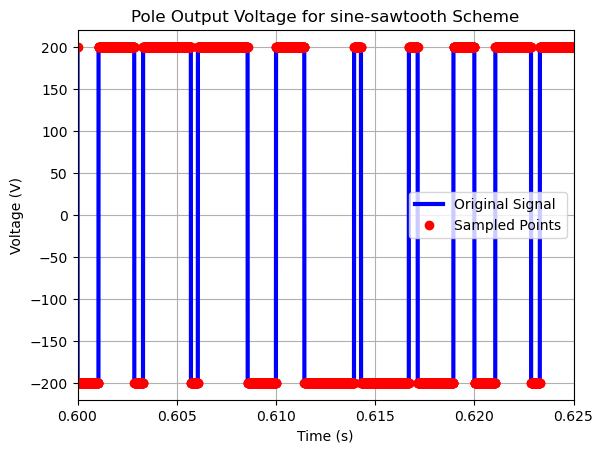

fsw: 3550 Hz


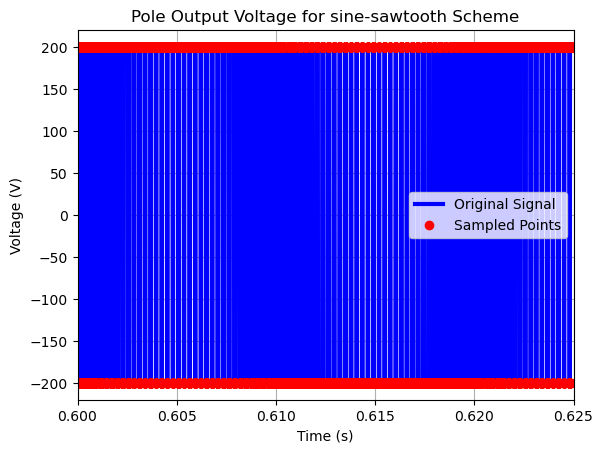

*--------------------------------------------*
SQUARE MODE Harmonic Spectrum
fsw: 350 Hz


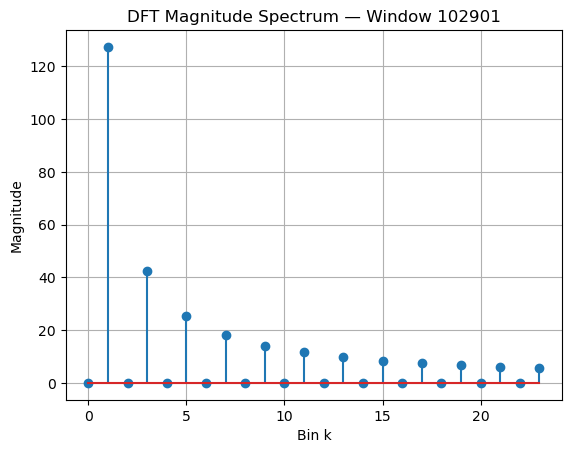

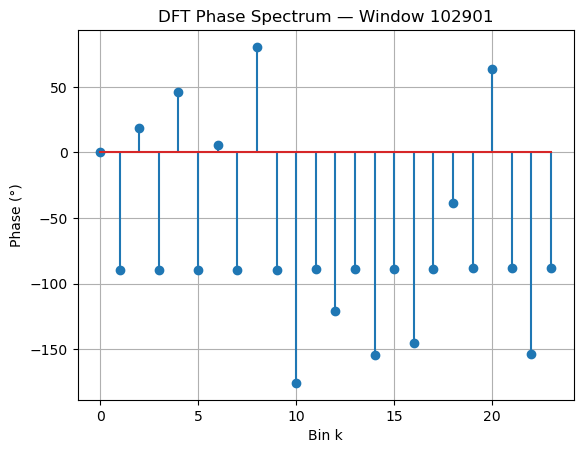

fsw: 3550 Hz


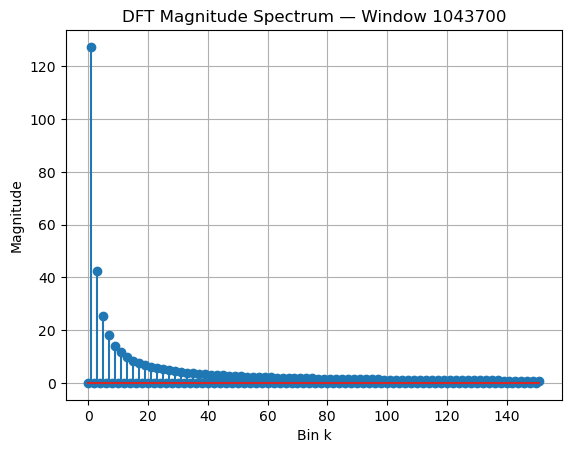

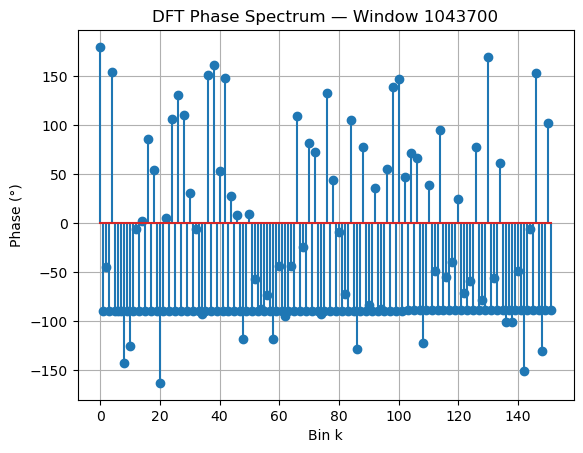

SINE-TRIANGLE MODE Harmonic Spectrum
fsw: 350 Hz


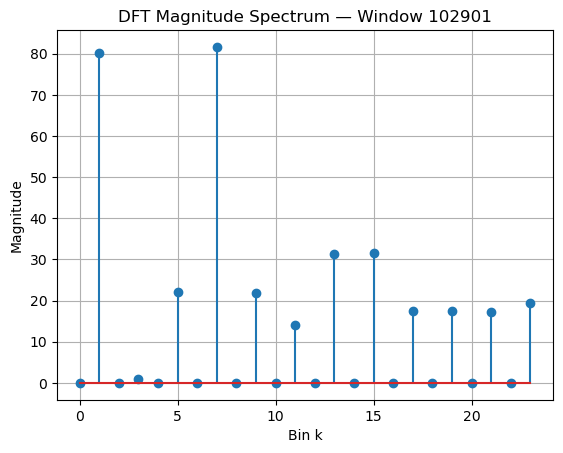

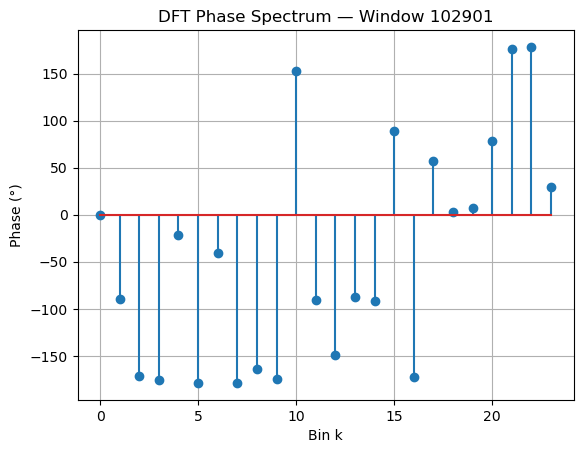

fsw: 3550 Hz


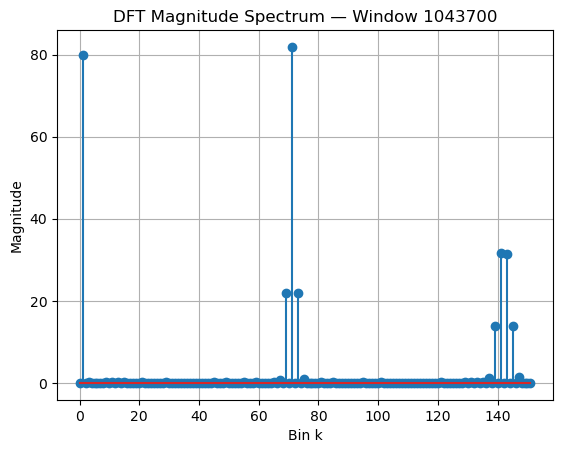

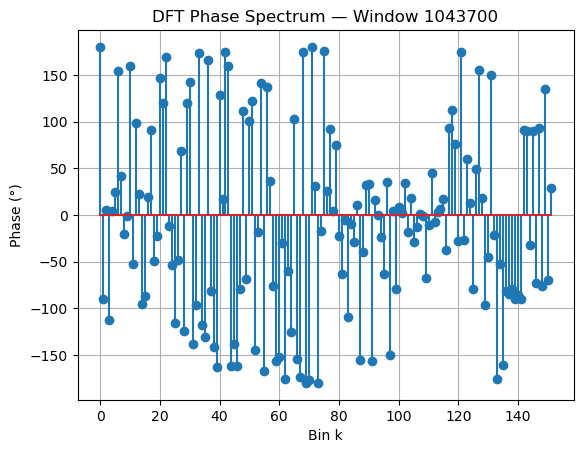

SINE-SAWTOOTH MODE Spectrum
fsw: 350 Hz


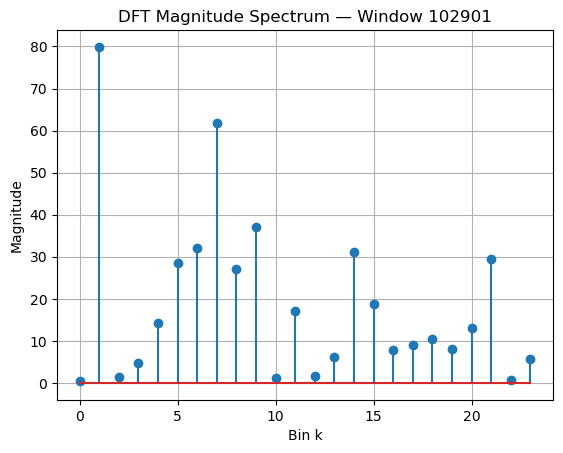

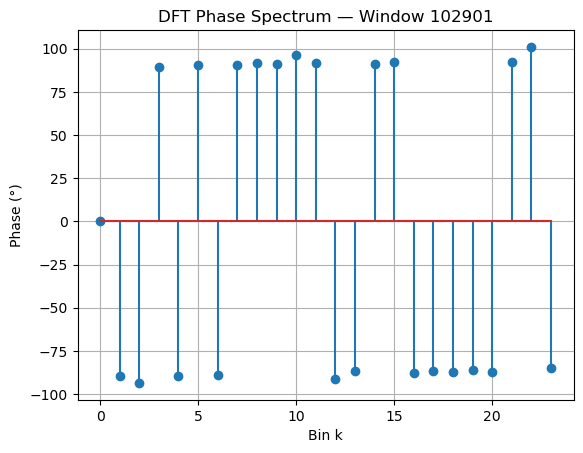

fsw: 3550 Hz


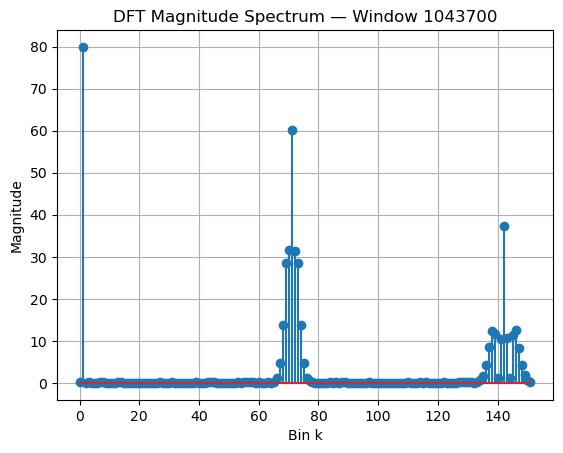

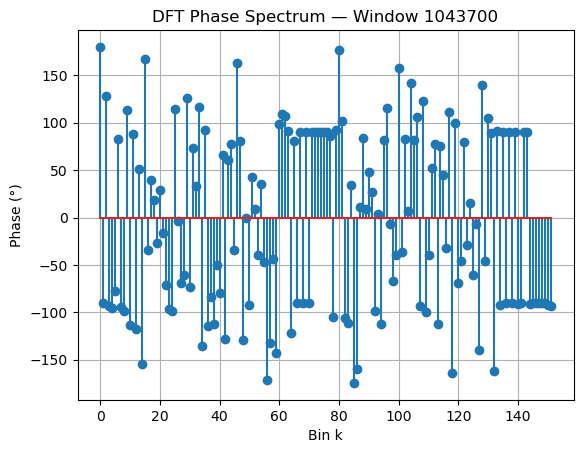

In [9]:
M = 2 * fsw//f1
M_low = 2 * fsw_low//f1

print("FOR AN fsw: {} Hz".format(fsw_low))
print("Pole Voltage Fundamental RMS for {0} scheme: {1:0.3f} V, {2} scheme: {3:0.3f} V, {4} scheme: {5:0.3f} V".format(VSC4.pwm,Vsq_f1,VSC5.pwm,Vsine_trif1,VSC6.pwm,Vsine_swf1))
print("*--------------------------------------------*")
print("FOR AN fsw: {} Hz".format(fsw))
print("Pole Voltage Fundamental RMS for {0} scheme: {1:0.3f} V, {2} scheme: {3:0.3f} V, {4} scheme: {5:0.3f} V".format(VSC1.pwm,Vsq_f,VSC2.pwm,Vsine_trif,VSC3.pwm,Vsine_swf))
print("*--------------------------------------------*")
print("FOR AN fsw: {} Hz".format(fsw_low))
print("Pole Voltage THD for {0} scheme: {1:0.3f} %, {2} scheme: {3:0.3f} %, {4} scheme: {5:0.3f} %".format(VSC4.pwm,sqV4.computeTHD(),VSC5.pwm,sineTriV5.computeTHD(),VSC6.pwm,sineSawV6.computeTHD()))
print("*--------------------------------------------*")
print("FOR AN fsw: {} Hz".format(fsw))
print("Pole Voltage THD for {0} scheme: {1:0.3f} %, {2} scheme: {3:0.3f} %, {4} scheme: {5:0.3f} %".format(VSC1.pwm,sqV1.computeTHD(),VSC2.pwm,sineTriV2.computeTHD(),VSC3.pwm,sineSawV3.computeTHD()))

# VOLTAGE WAVEFORMS
print("*--------------------------------------------*")
print("SQUARE MODE Voltages")
sqPWM = PWM(Ma,1,3,0)
sqPWM.SquareWave(np.arange(0,tend,0.001e-3),1)
print("fsw: {} Hz".format(fsw_low))
VSC4.plotWaveform([600e-3,625e-3])
print("fsw: {} Hz".format(fsw))
VSC1.plotWaveform([600e-3,625e-3])
print("SINE-TRIANGLE MODE Voltages")
sineTriPWM = PWM(Ma,1,3,0)
sineTriPWM.SineTriangle(np.arange(0,tend,0.001e-3),1)
print("fsw: {} Hz".format(fsw_low))
VSC5.plotWaveform([600e-3,625e-3])
print("fsw: {} Hz".format(fsw))
VSC2.plotWaveform([600e-3,625e-3])
print("SINE-SAWTOOTH MODE Voltages")
sineSawPWM = PWM(Ma,1,3,0)
sineSawPWM.SineSawtooth(np.arange(0,tend,0.001e-3),1)
print("fsw: {} Hz".format(fsw_low))
VSC6.plotWaveform([600e-3,625e-3])
print("fsw: {} Hz".format(fsw))
VSC3.plotWaveform([600e-3,625e-3])
print("*--------------------------------------------*")
print("SQUARE MODE Harmonic Spectrum")
print("fsw: {} Hz".format(fsw_low))
sqV4.plotSpectrum(M_low + 10)
print("fsw: {} Hz".format(fsw))
sqV1.plotSpectrum(M + 10)
print("SINE-TRIANGLE MODE Harmonic Spectrum")
print("fsw: {} Hz".format(fsw_low))
sineTriV5.plotSpectrum(M_low + 10)
print("fsw: {} Hz".format(fsw))
sineTriV2.plotSpectrum(M+ 10)
print("SINE-SAWTOOTH MODE Spectrum")
print("fsw: {} Hz".format(fsw_low))
sineSawV6.plotSpectrum(M_low + 10)
print("fsw: {} Hz".format(fsw))
sineSawV3.plotSpectrum(M + 10)


FOR AN fsw: 350 Hz
Grid Injected Current Fundamental RMS for square scheme: 9.459 A, sine-triangle scheme: 11.743 A, sine-sawtooth scheme: 11.398 A
*--------------------------------------------*
FOR AN fsw: 3550 Hz
Grid Injected Current Fundamental RMS for square scheme: 9.451 A, sine-triangle scheme: 11.272 A, sine-sawtooth scheme: 11.563 A
*--------------------------------------------*
FOR AN fsw: 350 Hz
Grid Injected Current THD for square scheme: 73.380 %, sine-triangle scheme: 52.670 %, sine-sawtooth scheme: 55.592 %
*--------------------------------------------*
FOR AN fsw: 3550 Hz
Grid Injected Current THD for square scheme: 73.385 %, sine-triangle scheme: 5.630 %, sine-sawtooth scheme: 6.737 %
*--------------------------------------------*
SQUARE MODE Grid Injected Current
fsw: 350 Hz


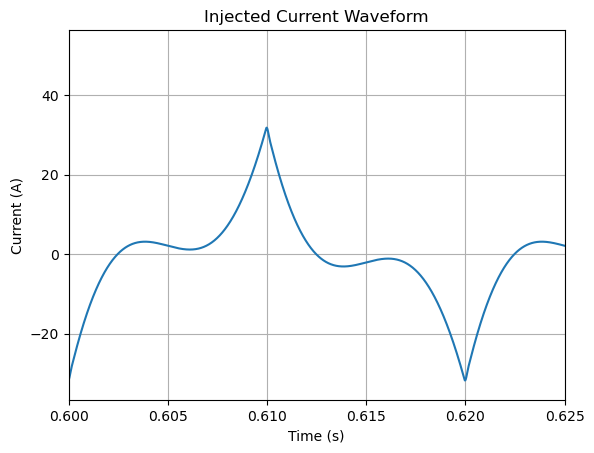

fsw: 3550 Hz


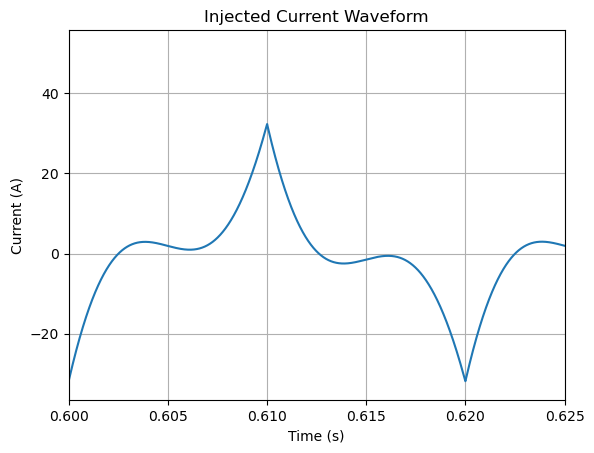

SINE-TRIANGLE MODE Grid Injected Current
fsw: 350 Hz


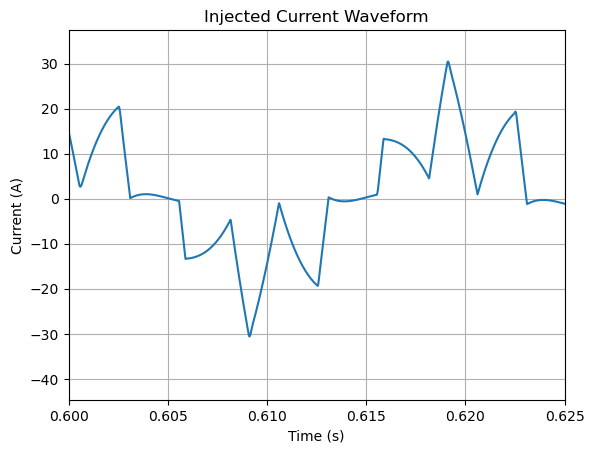

fsw: 3550 Hz


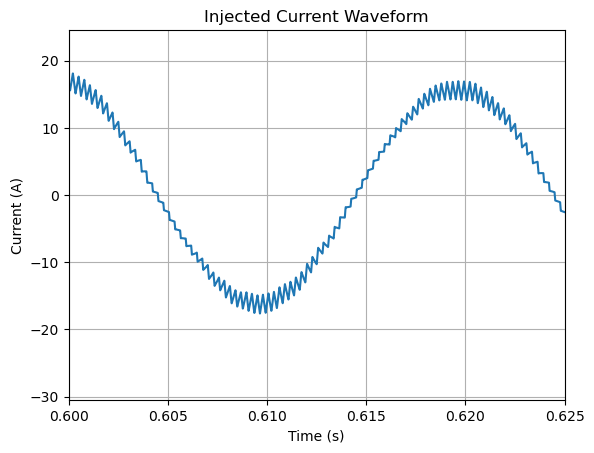

SINE-SAWTOOTH MODE Grid Injected Current
fsw: 350 Hz


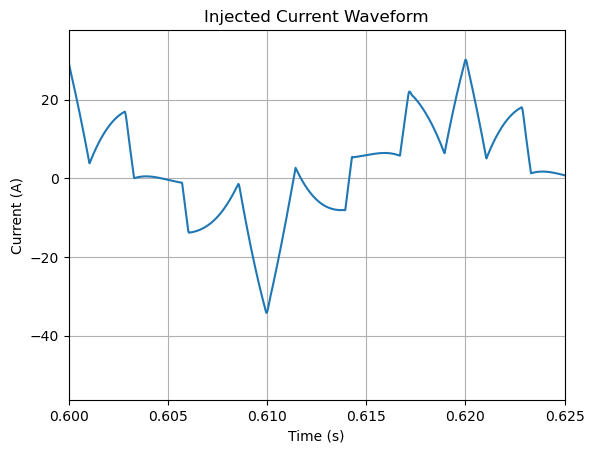

fsw: 3550 Hz


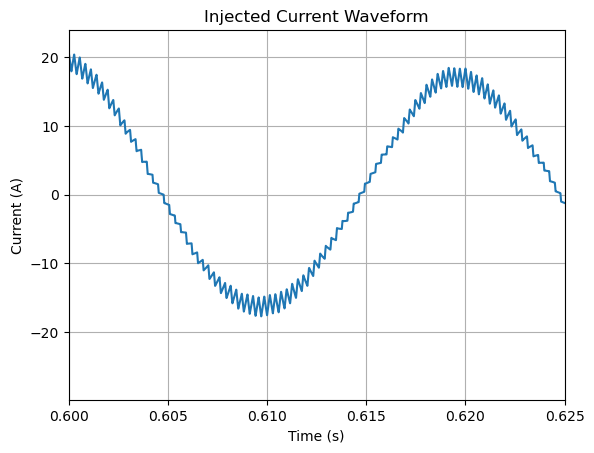

*--------------------------------------------*
SQUARE MODE Harmonic Spectrum
fsw: 350 Hz


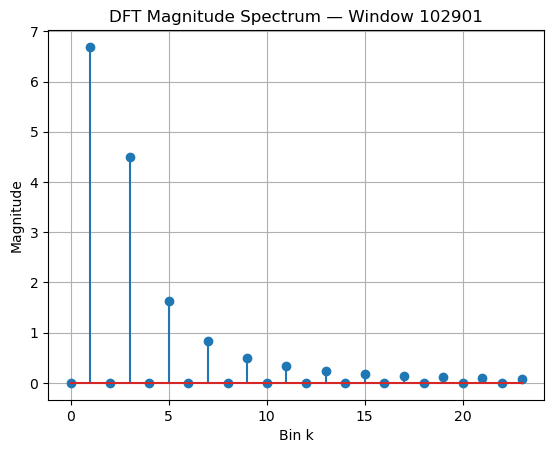

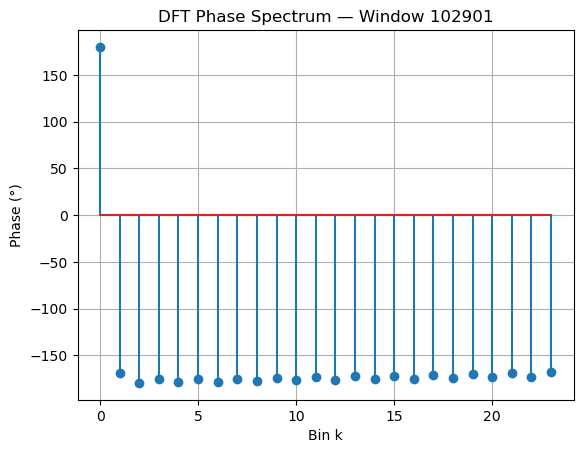

fsw: 3550 Hz


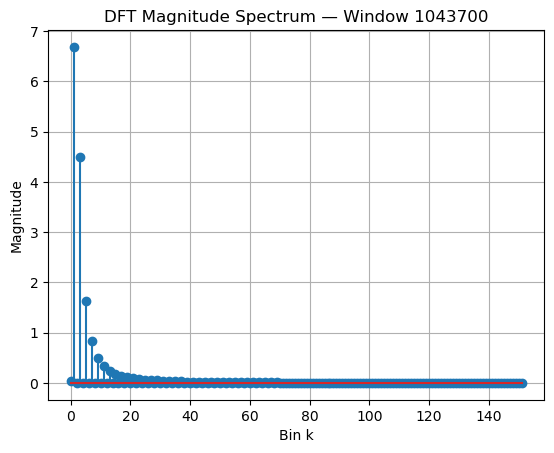

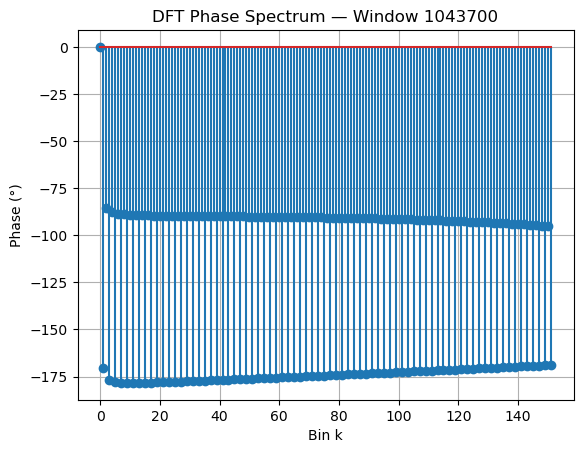

SINE-TRIANGLE MODE Harmonic Spectrum
fsw: 350 Hz


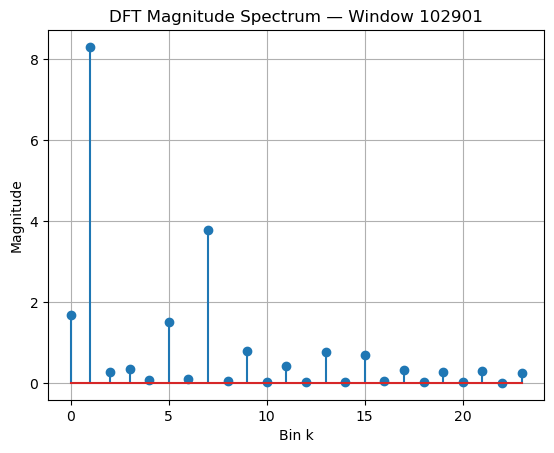

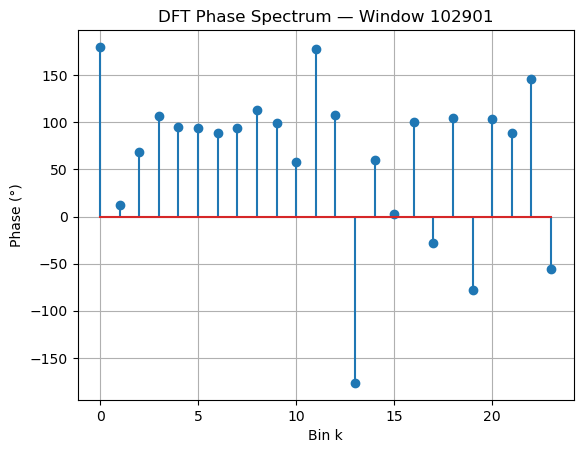

fsw: 3550 Hz


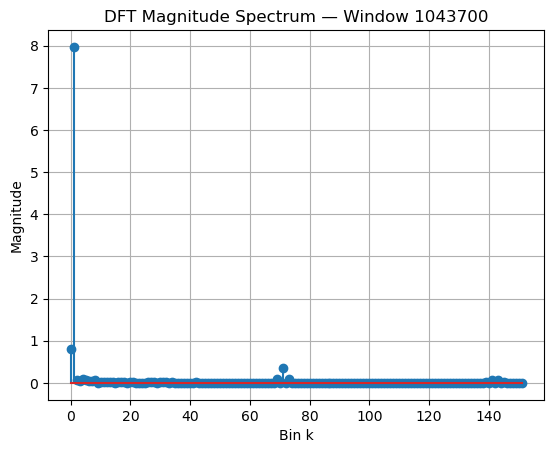

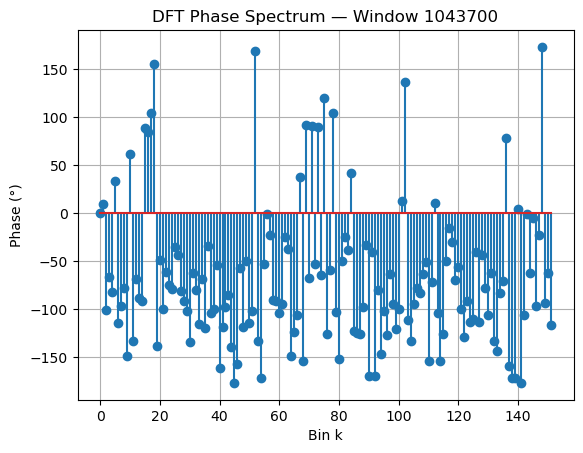

SINE-SAWTOOTH MODE Spectrum
fsw: 350 Hz


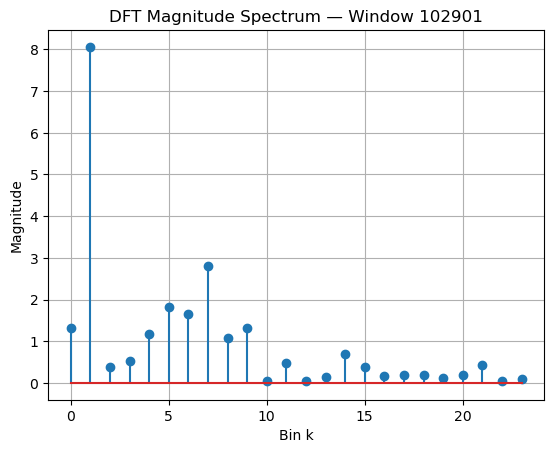

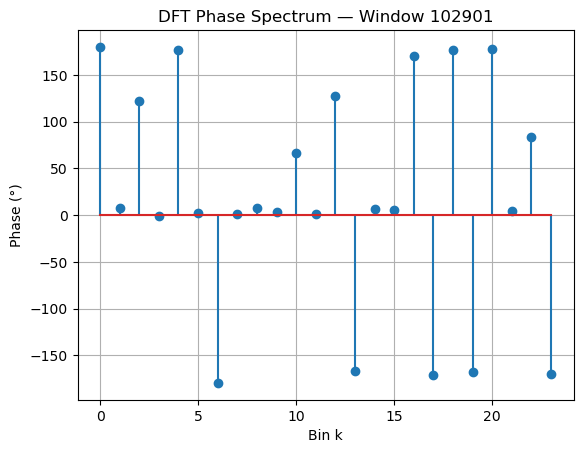

fsw: 3550 Hz


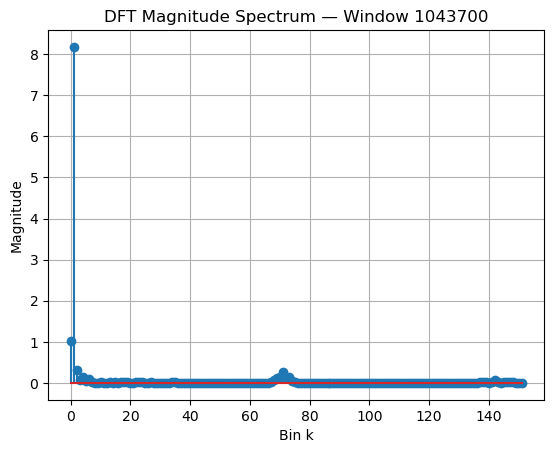

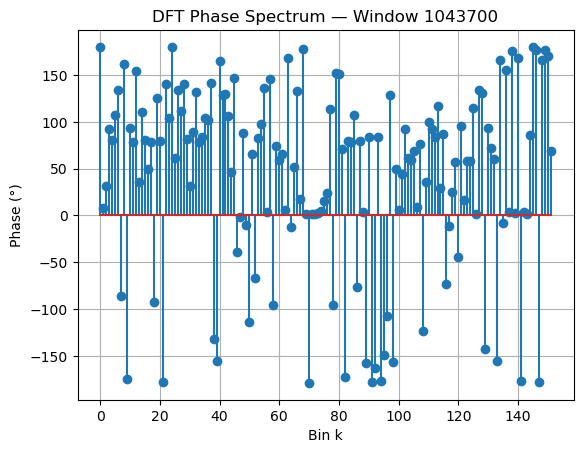

In [11]:
M = 2 * fsw//f1
M_low = 2 * fsw_low//f1

print("FOR AN fsw: {} Hz".format(fsw_low))
print("Grid Injected Current Fundamental RMS for {0} scheme: {1:0.3f} A, {2} scheme: {3:0.3f} A, {4} scheme: {5:0.3f} A".format(VSC4.pwm,Isq_f1,VSC5.pwm,IsineTri_f1,VSC6.pwm,IsineSaw_f1))
print("*--------------------------------------------*")
print("FOR AN fsw: {} Hz".format(fsw))
print("Grid Injected Current Fundamental RMS for {0} scheme: {1:0.3f} A, {2} scheme: {3:0.3f} A, {4} scheme: {5:0.3f} A".format(VSC1.pwm,Isq_f,VSC2.pwm,IsineTri_f,VSC3.pwm,IsineSaw_f))
print("*--------------------------------------------*")
print("FOR AN fsw: {} Hz".format(fsw_low))
print("Grid Injected Current THD for {0} scheme: {1:0.3f} %, {2} scheme: {3:0.3f} %, {4} scheme: {5:0.3f} %".format(VSC4.pwm,dftIsq1.computeTHD(),VSC5.pwm,dftIspwm1.computeTHD(),VSC6.pwm,dftIsaw1.computeTHD()))
print("*--------------------------------------------*")
print("FOR AN fsw: {} Hz".format(fsw))
print("Grid Injected Current THD for {0} scheme: {1:0.3f} %, {2} scheme: {3:0.3f} %, {4} scheme: {5:0.3f} %".format(VSC1.pwm,dftIsq.computeTHD(),VSC2.pwm,dftIspwm.computeTHD(),VSC3.pwm,dftIsaw.computeTHD()))

# CURRENT WAVEFORMS
print("*--------------------------------------------*")
print("SQUARE MODE Grid Injected Current")
print("fsw: {} Hz".format(fsw_low))
sqInjctn1.plotWaveform([600e-3,625e-3])
print("fsw: {} Hz".format(fsw))
sqInjctn.plotWaveform([600e-3,625e-3])
print("SINE-TRIANGLE MODE Grid Injected Current")
print("fsw: {} Hz".format(fsw_low))
sineTriInjctn1.plotWaveform([600e-3,625e-3])
print("fsw: {} Hz".format(fsw))
sineTriInjctn.plotWaveform([600e-3,625e-3])
print("SINE-SAWTOOTH MODE Grid Injected Current")
print("fsw: {} Hz".format(fsw_low))
sineSawInjctn1.plotWaveform([600e-3,625e-3])
print("fsw: {} Hz".format(fsw))
sineSawInjctn.plotWaveform([600e-3,625e-3])
print("*--------------------------------------------*")
print("SQUARE MODE Harmonic Spectrum")
print("fsw: {} Hz".format(fsw_low))
dftIsq1.plotSpectrum(M_low + 10)
print("fsw: {} Hz".format(fsw))
dftIsq.plotSpectrum(M + 10)
print("SINE-TRIANGLE MODE Harmonic Spectrum")
print("fsw: {} Hz".format(fsw_low))
dftIspwm1.plotSpectrum(M_low + 10)
print("fsw: {} Hz".format(fsw))
dftIspwm.plotSpectrum(M + 10)
print("SINE-SAWTOOTH MODE Spectrum")
print("fsw: {} Hz".format(fsw_low))
dftIsaw1.plotSpectrum(M_low + 10)
print("fsw: {} Hz".format(fsw))
dftIsaw.plotSpectrum(M + 10)


## 8. Comparison of Numerical Results (for $f_{sw} = 3550Hz$)

| PWM Scheme | $V_{01}$ RMS Theoretical (V) | $V_{01}$ RMS Observed (V) | Voltage THD (%) |
|----------|------------------------|-------------|-------------|
| Square Wave | $$180.0633$$ | $$180.063$$ | $$48.343$$ |
| Sine-Triangle | $$113.1371$$ | $$113.027$$ | $$145.983$$ | 
| Sine-Sawtooth | $$113.1371$$ | $$113.046$$ | $$145.947$$ |

| PWM Scheme | $I_{g01}$ RMS Theoretical (A) | $I_{g01}$ RMS Observed (A) | Current THD (%) |
|----------|------------------------|-------------|-------------|
| Square Wave | $$9.4504$$ | $$9.451$$ | $$73.385$$ |
| Sine-Triangle | $$11.588$$ | $$11.743$$ | $$5.63$$ | 
| Sine-Sawtooth | $$11.588$$ | $$11.398$$ | $$6.737$$ |

---

## Comparison of Switching Strategies (Based on Simulation Results)

| Feature | Square Wave | Sine-Triangle PWM (SPWM) | Sine-Sawtooth PWM |
|--------|------------|---------------------------|-------------------|
| Switching Frequency | Fundamental (50 Hz) | High (preferred) (10 kHz) | High (preferred) (10 kHz) |
| Switching Function $s(t)$ | Square wave | PWM pulses (triangle carrier) | PWM pulses (sawtooth carrier) |
| Pole Voltage $v_p(t)$ | Two-level square wave | High-frequency switching waveform | High-frequency switching waveform |
| Harmonic Location (Voltage) | Low-frequency harmonics | High-frequency harmonics (around $m\times \frac{f_{sw}}{f_1}\pm k$) | High-frequency harmonics |
| Injected Current $i(t)$ | Highly distorted | Nearly sinusoidal | Nearly sinusoidal (slightly more ripple) |
| Current Ripple | Large | Small | Slightly higher than SPWM |
| FFT of Pole Voltage | Strong low-order harmonics | Harmonics shifted to high frequency | Similar to SPWM but less symmetric |
| FFT of Current | Significant harmonics | Dominant fundamental, low harmonics | Slightly higher harmonics than SPWM |
| THD of Current | High (from simulation) | Lowest (from simulation) | Slightly higher than SPWM |
| Effect of Inductor | Limited filtering | Very effective filtering | Effective filtering |
| Overall Performance | Poor | Best | Good |

---

### Key Observations:

- Square‑wave switching produces strong low‑frequency harmonics, leading to poor current quality.
- sine-PWM shifts harmonics to higher frequencies, which are effectively filtered by the inductor.
- sine-sawtooth PWM also shifts harmonics but results in slightly higher distortion due to its asymmetry.
- The injected current is smoothest in sine-PWM, confirming its superior harmonic performance.
- THD decreases at higher switching frequencies, which is why they are preferred over lower switching frequencies.
- For a waveform to exhibit lower THD, its shape must closely resemble a sine wave. In the sine‑triangle and sine‑sawtooth methods, however, the pole voltage waveforms are square‑shaped with more switching events, which is why their THD is higher than in square‑wave mode.
- The advantage of sine‑PWM techniques is that they shift harmonics to higher frequencies, allowing them to be filtered out by the R–L low‑pass filter.
- In the harmonic spectrum of sine‑triangle PWM, even harmonics are absent due to the half‑wave symmetric nature of the triangle wave. In contrast, sine‑sawtooth PWM produces both even and odd harmonics.
- The harmonics are concentrated around the $m\times \frac{f_{sw}}{f_1}\pm k$ bands, where $m = 0,1,2,3\cdots$, and for each m, $k = 0,1,2,3\cdots$


---